In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

import pybaseball

print("Environment ready")

Environment ready


In [14]:
from pybaseball import batting_stats

In [15]:
raw_data = batting_stats(2019, 2025)

In [16]:
df = raw_data[
    ["Season", "Name", "Team", "Age", "PA", "AVG", "OBP", "SLG", "Barrel%", "HardHit%"]]
df = df[df["Season"] != 2020]

In [17]:
player_counts = df["Name"].value_counts()

eligible_players = player_counts[player_counts >= 6].index

df = df[df["Name"].isin(eligible_players)].copy()

In [18]:
print("Shape: ", df.shape)


Shape:  (132, 10)


In [19]:
print(df.info())

<class 'pandas.DataFrame'>
Index: 132 entries, 14 to 841
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Season    132 non-null    int64  
 1   Name      132 non-null    str    
 2   Team      132 non-null    str    
 3   Age       132 non-null    int64  
 4   PA        132 non-null    int64  
 5   AVG       132 non-null    float64
 6   OBP       132 non-null    float64
 7   SLG       132 non-null    float64
 8   Barrel%   132 non-null    float64
 9   HardHit%  132 non-null    float64
dtypes: float64(5), int64(3), str(2)
memory usage: 13.5 KB
None


In [20]:
df["Name"].value_counts()

Name
Juan Soto                6
Freddie Freeman          6
Francisco Lindor         6
Mookie Betts             6
Trea Turner              6
Manny Machado            6
Paul Goldschmidt         6
Matt Olson               6
Dansby Swanson           6
Rafael Devers            6
Marcus Semien            6
Jose Ramirez             6
Vladimir Guerrero Jr.    6
Bryan Reynolds           6
Matt Chapman             6
Willy Adames             6
Pete Alonso              6
Eugenio Suarez           6
Nick Castellanos         6
Gleyber Torres           6
Josh Bell                6
Ryan McMahon             6
Name: count, dtype: int64

In [21]:
X = df[["Season", "Age", "PA", "OBP", "SLG", "Barrel%", "HardHit%"]]
y = df["AVG"]

X_np = X.to_numpy()
X_np = (X_np - X_np.mean(axis=0)) / X_np.std(axis=0) #standardizing columns
y_np = y.to_numpy()



In [22]:
!uv add pymc

Resolved 145 packages in 0.87ms
Audited 141 packages in 1ms


In [23]:
import pymc as pm

In [24]:
model_v1= pm.Model()

with model_v1:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=X.shape[1])
    sigma = pm.HalfNormal("sigma", sigma=1)
    mu = alpha + pm.math.dot(X_np, beta)
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=y_np)
    idata = pm.sample(1000,chains = 4, cores=8)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 21 seconds.


array([[<Axes: title={'center': 'alpha'}>,
        <Axes: title={'center': 'alpha'}>],
       [<Axes: title={'center': 'beta'}>,
        <Axes: title={'center': 'beta'}>],
       [<Axes: title={'center': 'sigma'}>,
        <Axes: title={'center': 'sigma'}>]], dtype=object)

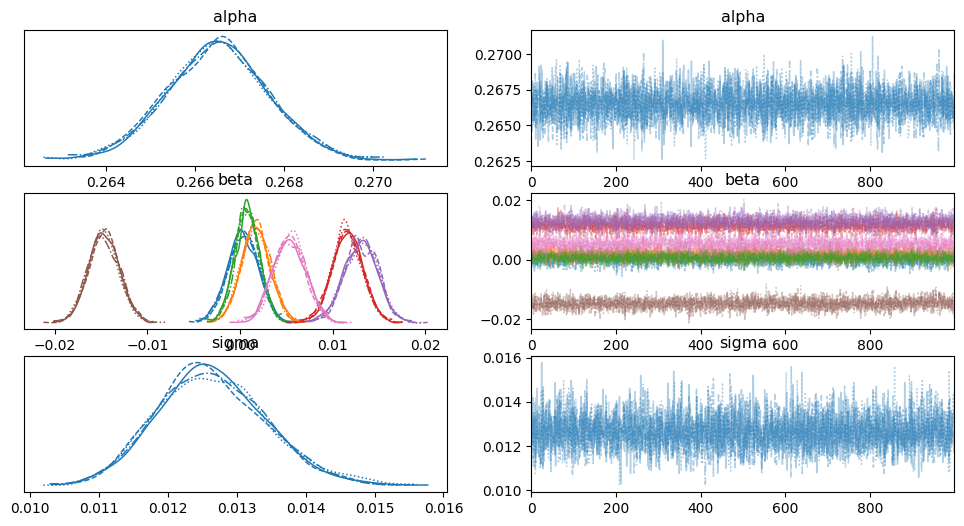

In [25]:
az.plot_trace(idata)